# GRU Seq2Seq

In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler 
from src.visualization import plot_forecast, plot_forecast_with_train
from src.models.rnn.rnn_seq2seq import RNNSeq2Seq, Encoder, Decoder
from src.models.rnn.train_rnn_seq2seq import train_rnn_seq2seq
from src.evaluation import evaluate, evaluate_by_depth
from src.models.rnn.data_preparing import (
    create_seq2seq_eval_loader,
    create_seq2seq_train_loader
)
from src.models.rnn.predict import predict_seq2seq
from src.seed import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
set_seed(SEED)

In [5]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [6]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [7]:
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', 
               '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', 
               '48-1 (9)', '48-1 (10)']
feature_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'is_anomaly']

history_len = 365
horizon = 30

df_train_full = df_train_full[feature_cols + target_cols]
df_train = df_train[feature_cols + target_cols]
df_val = df_val[feature_cols + target_cols]
df_test = df_test[feature_cols + target_cols]

In [8]:
batch_size = 64

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()


train_loader = create_seq2seq_train_loader(
    df=df_train,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    batch_size=batch_size
)

full_train_loader = create_seq2seq_train_loader(
    df=df_train_full,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=full_feature_scaler,
    target_scaler=full_target_scaler,
    batch_size=batch_size
)

val_loader = create_seq2seq_eval_loader(
    df_eval=df_val,
    df_start=df_train,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    batch_size=batch_size
)

In [7]:
input_size = len(feature_cols) + len(target_cols)
feature_size = len(feature_cols)
target_size = len(target_cols)
criterion = nn.MSELoss()

def objective(trial):
    set_seed(SEED + trial.number)
    hidden_size = trial.suggest_int('hidden_size', 16, 160, step=16)
    num_layers = trial.suggest_int('num_layers', 1, 4)
    
    if num_layers == 1:
        dropout = 0.0
    else:
        dropout = trial.suggest_float('dropout', 0.0, 0.4)
    
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    
    encoder_trial = Encoder(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        rnn_type='gru'
    )
    
    decoder_trial = Decoder(
        feature_size=feature_size,
        target_size=target_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        rnn_type='gru'
    )
    
    model_trial = RNNSeq2Seq(
        encoder=encoder_trial,
        decoder=decoder_trial,
        target_size=len(target_cols)
    ).to(device)
    
    optimizer_trial = optim.AdamW(
        model_trial.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_trial,
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )
    model_trial, history = train_rnn_seq2seq(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        teacher_forcing_ratio=0.5,
        scheduler=scheduler,
        device=device,
        epochs=100,
        max_epochs_no_improvement=10,
        verbose=False
    )
    
    trial.set_user_attr('actual_dropout', dropout)
    trial.set_user_attr('best_epoch', history['best_epoch'])
    trial.set_user_attr('total_epochs', len(history['val_rmse']))
    
    best_val_rmse = float(history['best_val_rmse'][-1])
    return best_val_rmse

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=10)

print('Лучшие параметры: ', study.best_params)
print('Количество эпох в лучшем запуске: ', study.best_trial.user_attrs['total_epochs'])

[I 2026-06-13 00:14:25,310] A new study created in memory with name: no-name-c50d0e0c-551a-4e75-a9b0-31663eb2de3a
[I 2026-06-13 00:15:30,907] Trial 0 finished with value: 0.22002634406089783 and parameters: {'hidden_size': 64, 'num_layers': 4, 'dropout': 0.292797576724562, 'lr': 0.00015751320499779721, 'weight_decay': 2.0513382630874486e-05}. Best is trial 0 with value: 0.22002634406089783.


Early stopping on 72 epoch


[I 2026-06-13 00:15:50,282] Trial 1 finished with value: 0.2553291320800781 and parameters: {'hidden_size': 32, 'num_layers': 1, 'lr': 0.0005399484409787432, 'weight_decay': 0.00015930522616241006}. Best is trial 0 with value: 0.22002634406089783.


Early stopping on 40 epoch


[I 2026-06-13 00:15:57,251] Trial 2 finished with value: 0.24429826438426971 and parameters: {'hidden_size': 128, 'num_layers': 1, 'lr': 0.0008706020878304854, 'weight_decay': 0.000462258900102083}. Best is trial 0 with value: 0.22002634406089783.


...

Early stopping on 25 epoch


[I 2026-06-13 00:18:47,446] Trial 7 finished with value: 0.23707816004753113 and parameters: {'hidden_size': 16, 'num_layers': 4, 'dropout': 0.38625281322982374, 'lr': 0.0004138040112561013, 'weight_decay': 4.066563313514796e-05}. Best is trial 0 with value: 0.22002634406089783.


Early stopping on 58 epoch


[I 2026-06-13 00:19:56,322] Trial 8 finished with value: 0.9318287372589111 and parameters: {'hidden_size': 16, 'num_layers': 3, 'dropout': 0.17606099749584053, 'lr': 1.7541893487450798e-05, 'weight_decay': 9.7803370166594e-05}. Best is trial 0 with value: 0.22002634406089783.
[I 2026-06-13 00:21:15,491] Trial 9 finished with value: 0.25666388869285583 and parameters: {'hidden_size': 16, 'num_layers': 4, 'dropout': 0.10351199264000677, 'lr': 0.00021137059440645722, 'weight_decay': 4.201672054372529e-05}. Best is trial 0 with value: 0.22002634406089783.


Лучшие параметры:  {'hidden_size': 64, 'num_layers': 4, 'dropout': 0.292797576724562, 'lr': 0.00015751320499779721, 'weight_decay': 2.0513382630874486e-05}
Количество эпох в лучшем запуске:  73


In [8]:
encoder = Encoder(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    dropout=study.best_trial.user_attrs['actual_dropout'],
    rnn_type='gru'
)

decoder = Decoder(
    feature_size=feature_size,
    target_size=target_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    dropout=study.best_trial.user_attrs['actual_dropout'],
    rnn_type='gru'
)

model = RNNSeq2Seq(
    encoder=encoder,
    decoder=decoder,
    target_size=len(target_cols)
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=study.best_params['lr'],
    weight_decay=study.best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

model, _ = train_rnn_seq2seq(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    teacher_forcing_ratio=0.5,
    scheduler=scheduler,
    device=device,
    epochs=study.best_trial.user_attrs['best_epoch'],
    max_epochs_no_improvement=10,
    verbose=True
)

Epoch 1/63 | Train Loss: 0.7870
Epoch 2/63 | Train Loss: 0.7566
Epoch 3/63 | Train Loss: 0.7192
Epoch 4/63 | Train Loss: 0.6582
Epoch 5/63 | Train Loss: 0.5557
Epoch 6/63 | Train Loss: 0.3994
Epoch 7/63 | Train Loss: 0.2873
Epoch 8/63 | Train Loss: 0.2350
Epoch 9/63 | Train Loss: 0.2052
Epoch 10/63 | Train Loss: 0.1735
Epoch 11/63 | Train Loss: 0.1535
Epoch 12/63 | Train Loss: 0.1354
Epoch 13/63 | Train Loss: 0.1190
Epoch 14/63 | Train Loss: 0.1020
Epoch 15/63 | Train Loss: 0.0837
Epoch 16/63 | Train Loss: 0.0692
Epoch 17/63 | Train Loss: 0.0540
Epoch 18/63 | Train Loss: 0.0467
Epoch 19/63 | Train Loss: 0.0402
Epoch 20/63 | Train Loss: 0.0360
Epoch 21/63 | Train Loss: 0.0336
Epoch 22/63 | Train Loss: 0.0316
Epoch 23/63 | Train Loss: 0.0303
Epoch 24/63 | Train Loss: 0.0296
Epoch 25/63 | Train Loss: 0.0288
Epoch 26/63 | Train Loss: 0.0284
Epoch 27/63 | Train Loss: 0.0278
Epoch 28/63 | Train Loss: 0.0271
Epoch 29/63 | Train Loss: 0.0271
Epoch 30/63 | Train Loss: 0.0260
Epoch 31/63 | Train

In [ ]:
# model_path = 'models/gru_seq2seq_v1.pth'
# weights_path = 'models/gru_seq2seq_v1_weights.pth'

# torch.save(model, model_path)
# torch.save(model.state_dict(), weights_path)

# model = torch.load(model_path, weights_only=False)

                              RMSE       MAE        ME       NSE
Значение для всех глубин  0.925913  0.705433 -0.122004  0.916767
      48-1 (0)
RMSE  3.156791
MAE    2.49695
ME    0.122928
NSE   0.885071


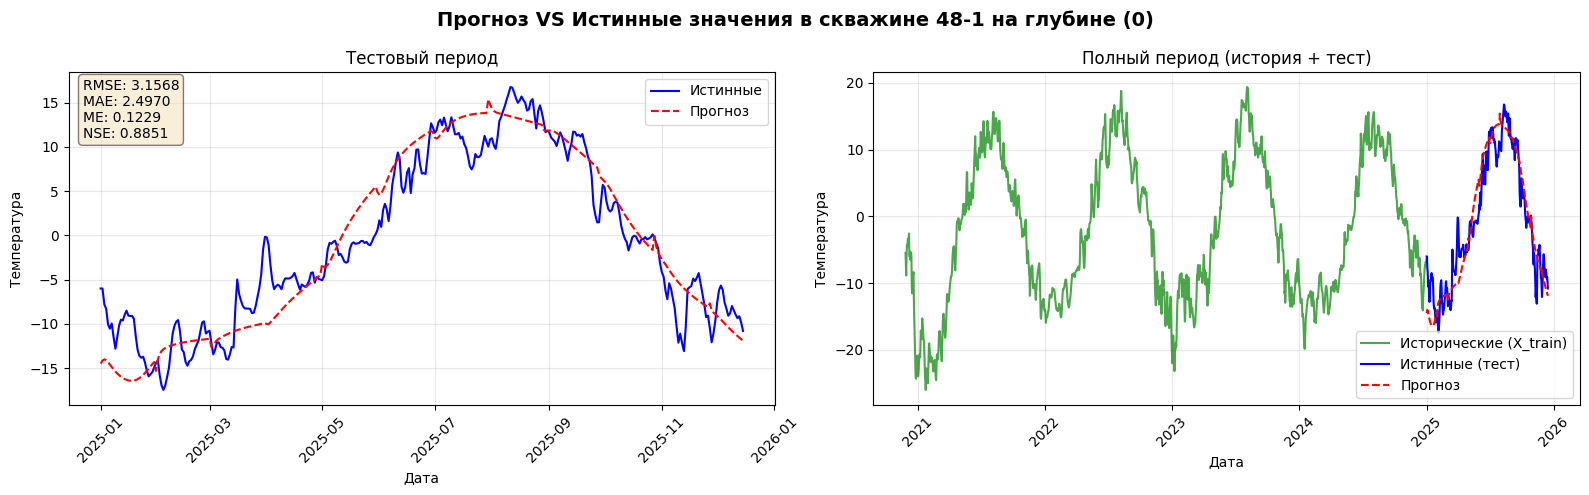

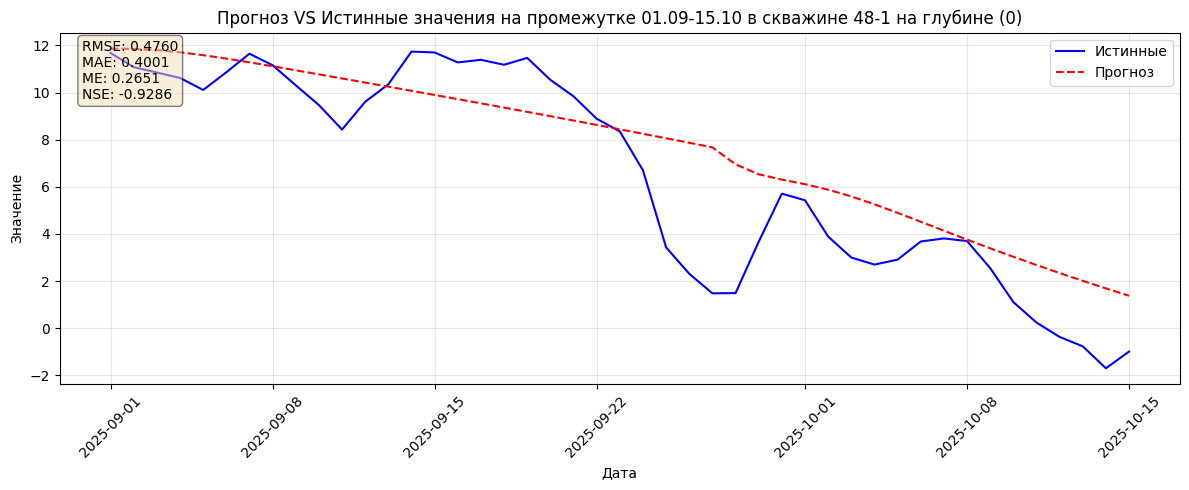

     48-1 (0,5)
RMSE   2.138956
MAE    1.640538
ME     0.002707
NSE    0.906835


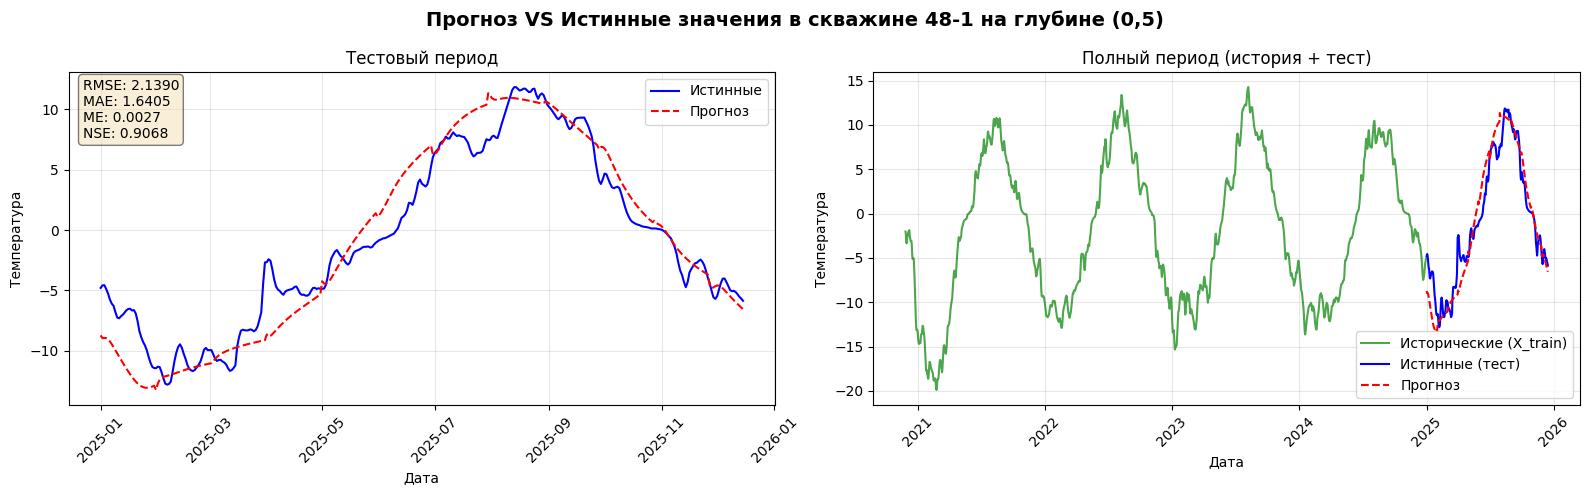

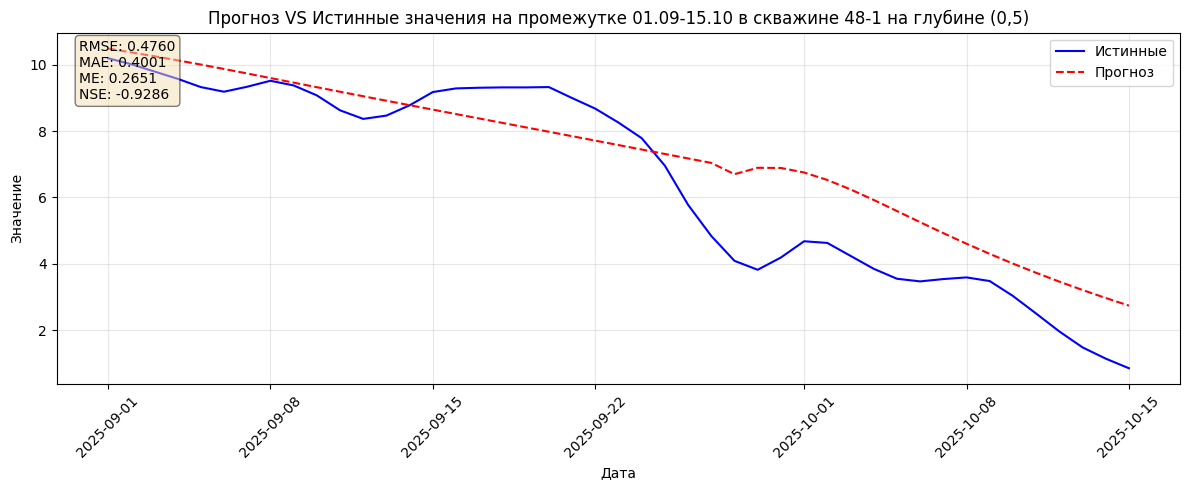

      48-1 (1)
RMSE  1.538156
MAE   1.159504
ME   -0.044917
NSE   0.919272


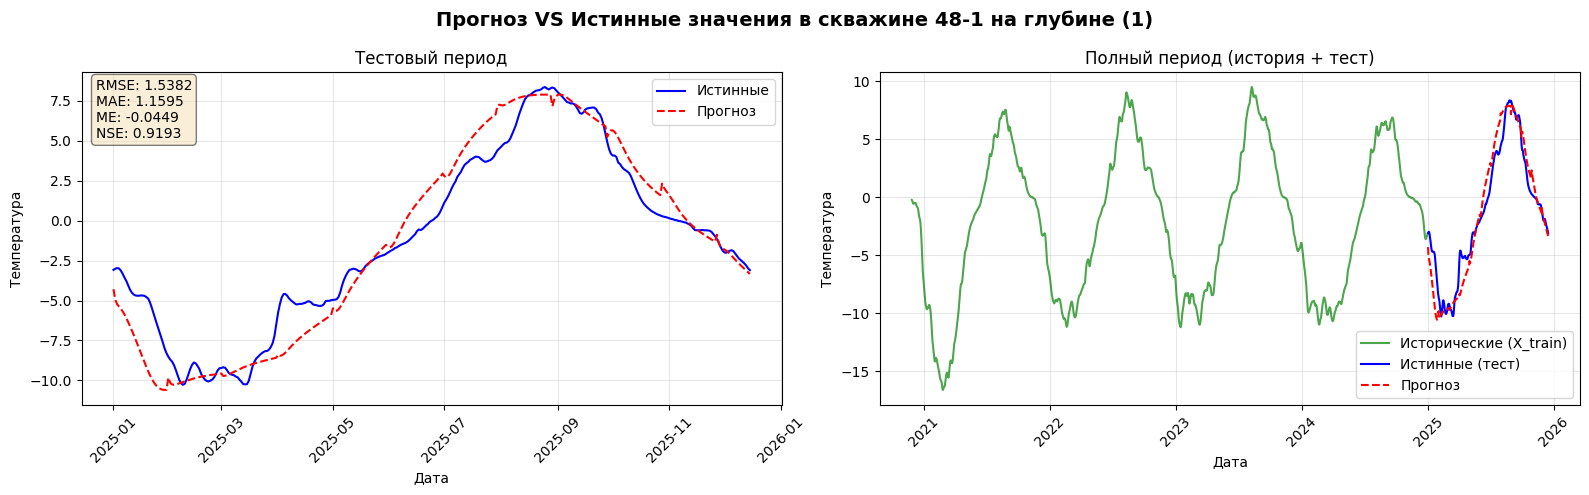

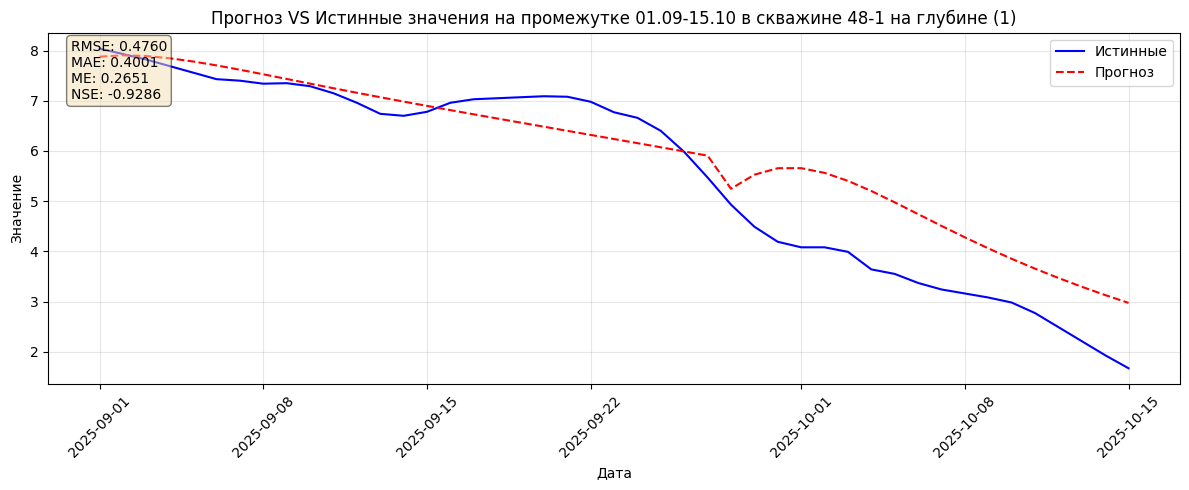

     48-1 (1,5)
RMSE   1.331255
MAE    1.064765
ME    -0.128593
NSE    0.907674


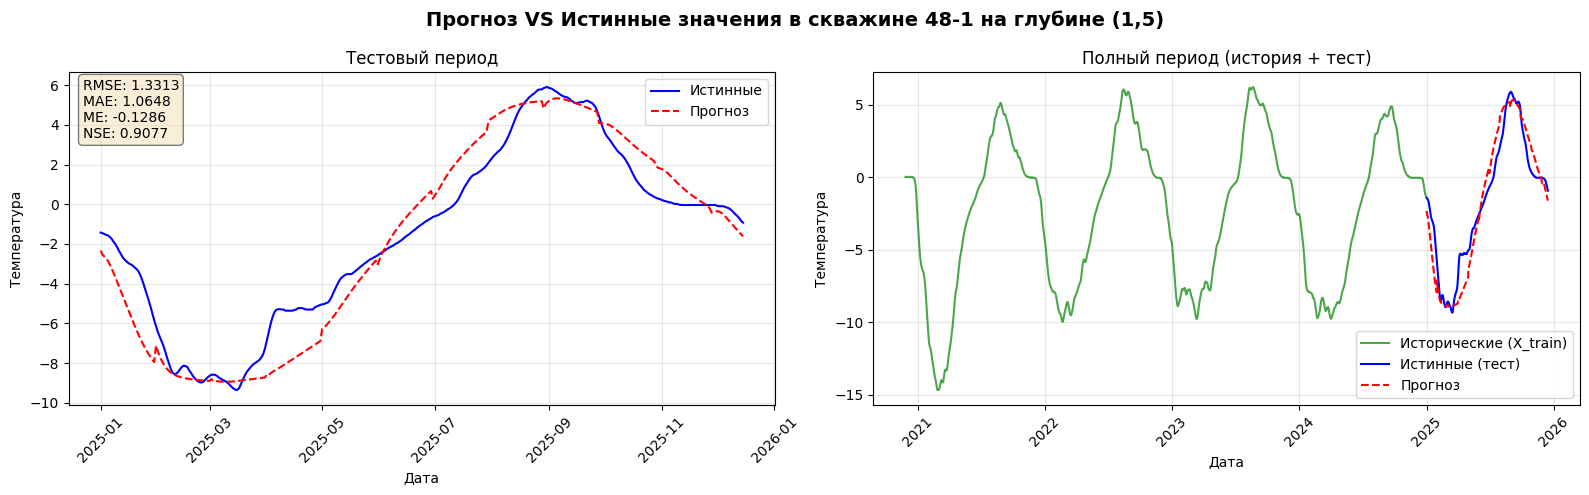

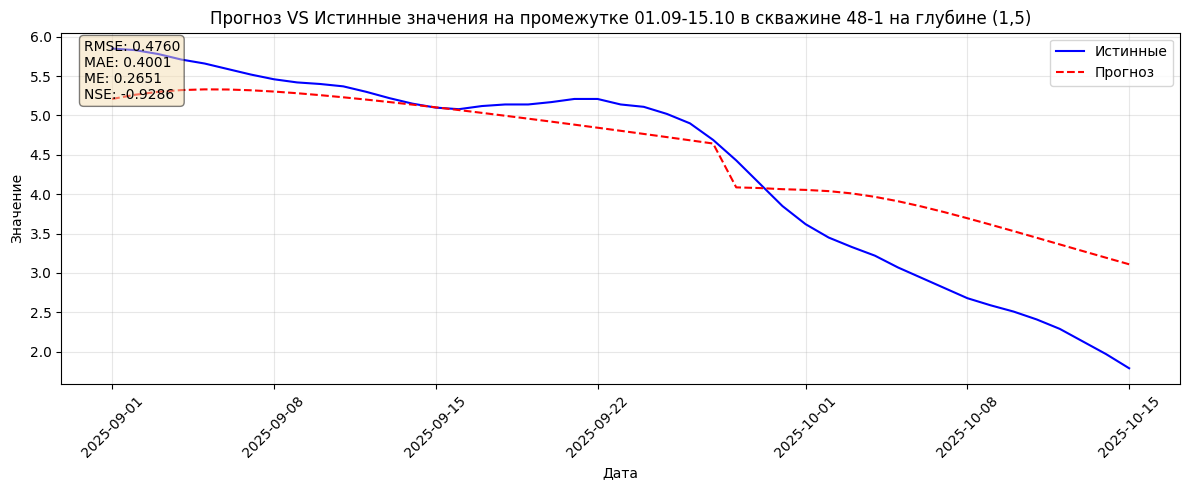

      48-1 (2)
RMSE  1.071177
MAE   0.843849
ME   -0.247541
NSE   0.906702


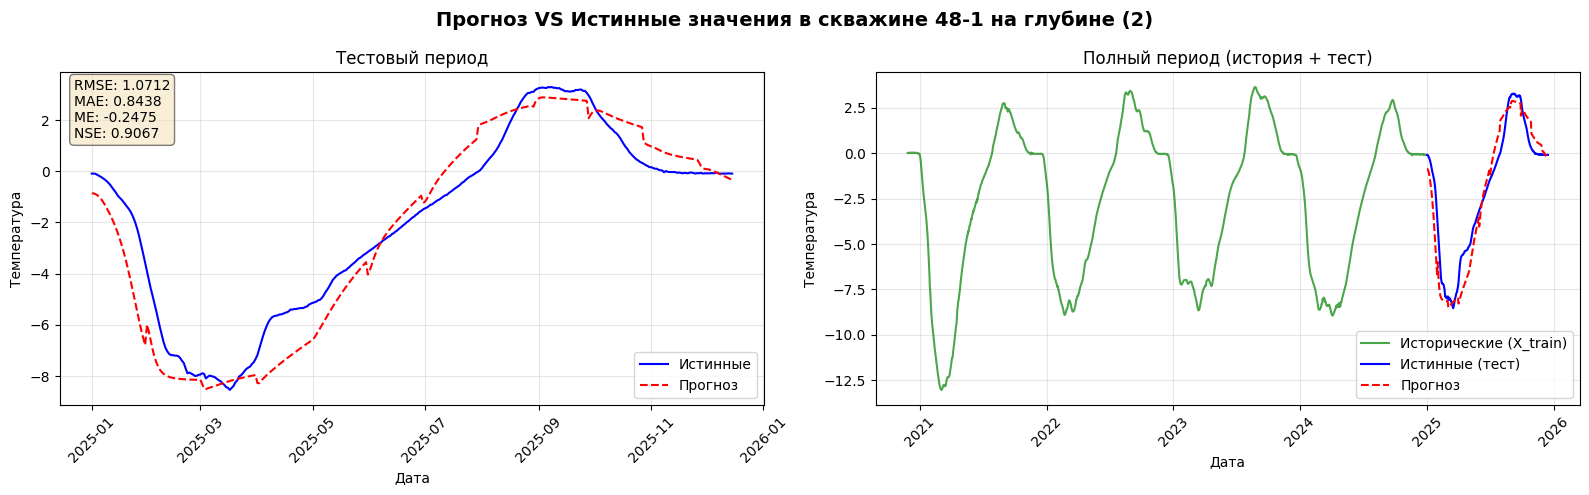

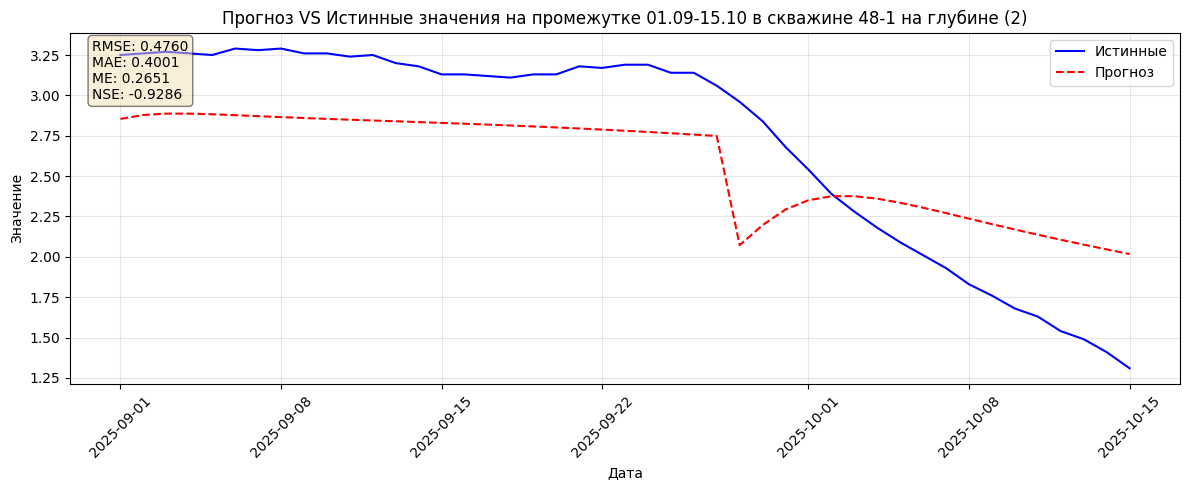

     48-1 (2,5)
RMSE   0.868217
MAE    0.593028
ME    -0.263398
NSE    0.901778


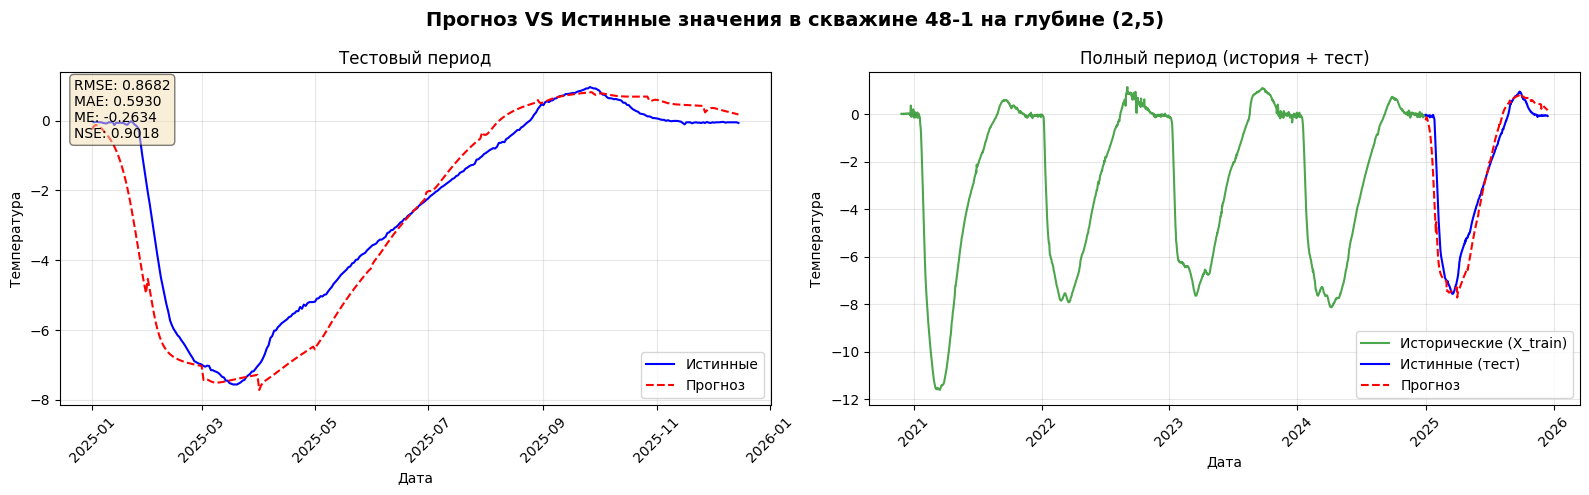

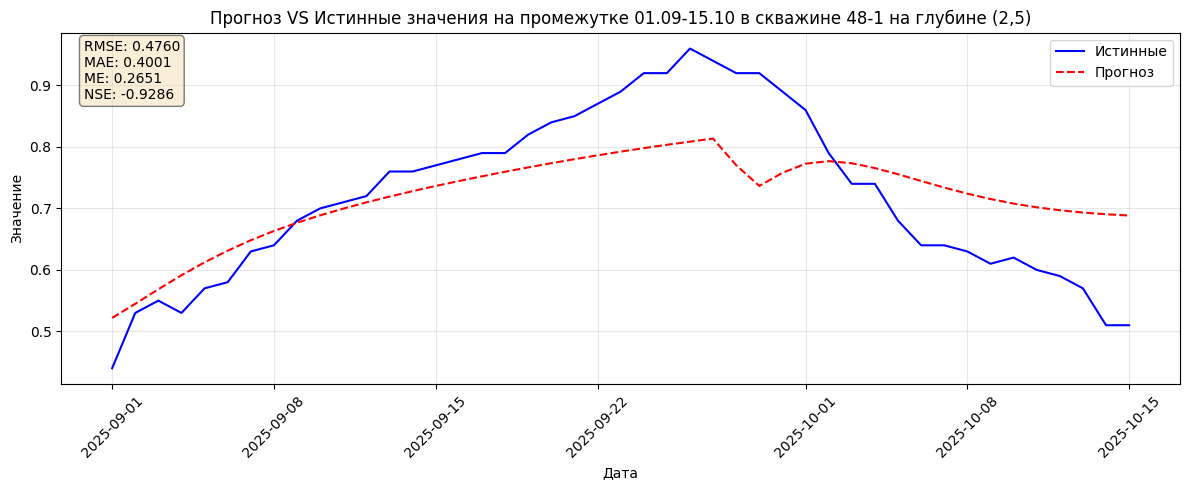

      48-1 (3)
RMSE  0.721348
MAE   0.475973
ME   -0.295964
NSE   0.912638


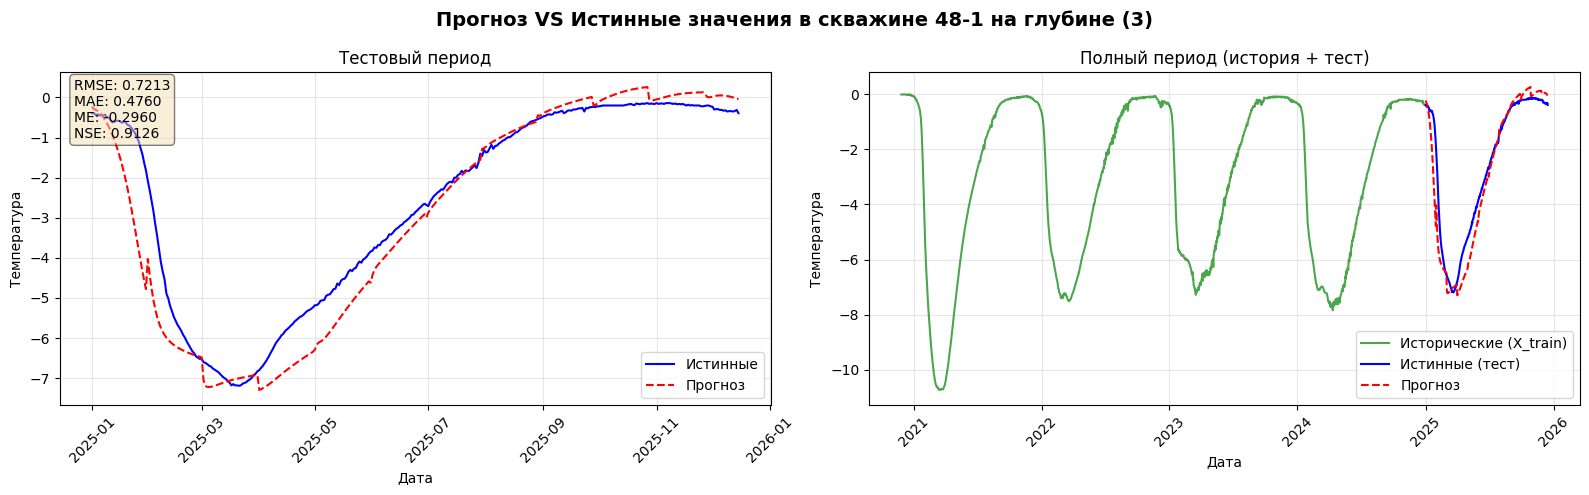

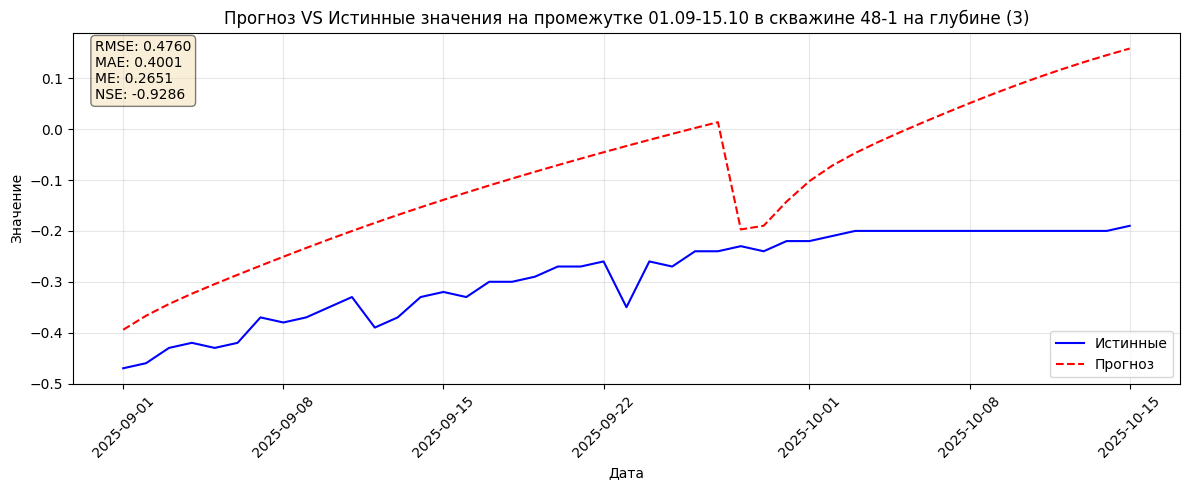

     48-1 (3,5)
RMSE   0.623835
MAE    0.444288
ME     -0.21742
NSE    0.922098


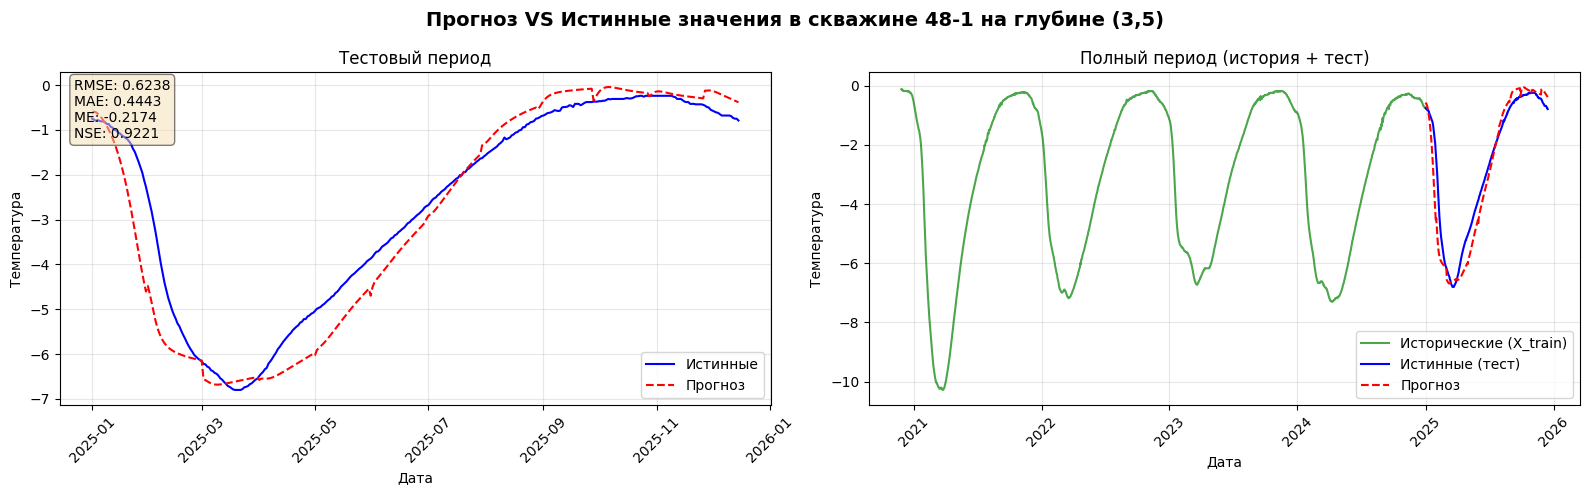

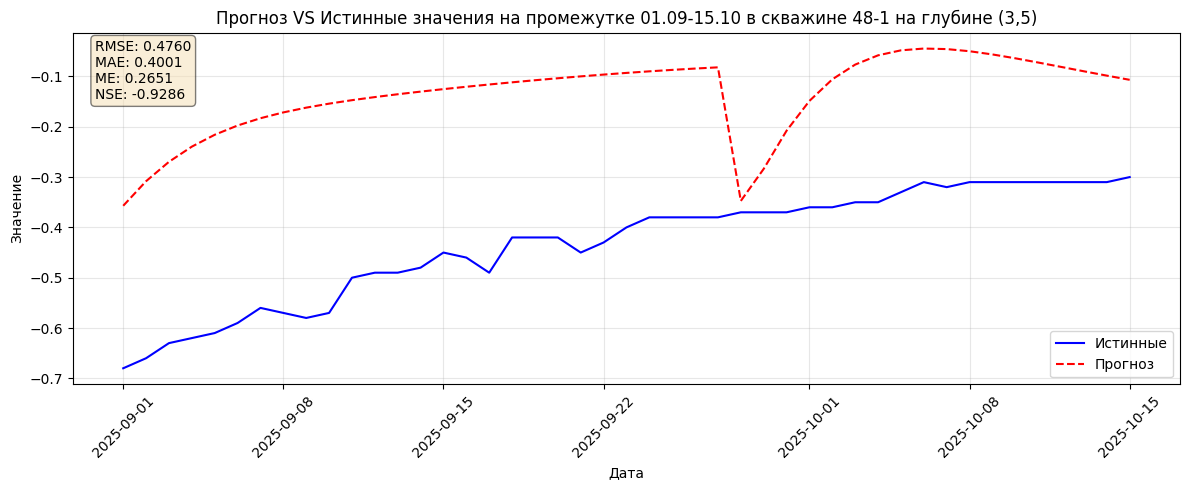

      48-1 (4)
RMSE  0.567651
MAE   0.422211
ME   -0.194037
NSE   0.921435


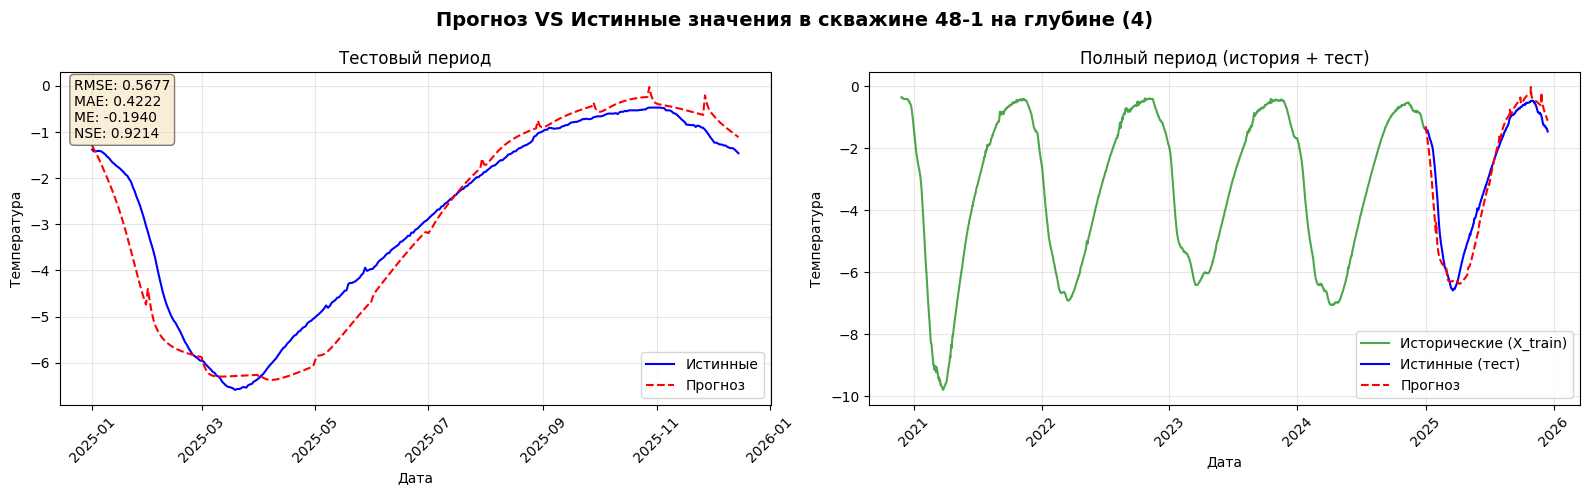

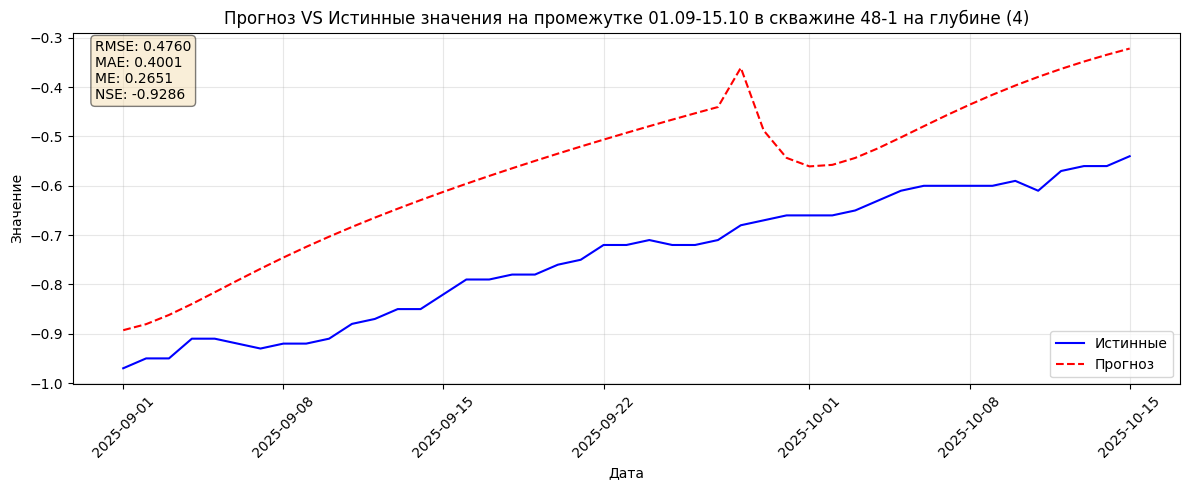

     48-1 (4,5)
RMSE   0.564674
MAE    0.425556
ME    -0.196088
NSE    0.914181


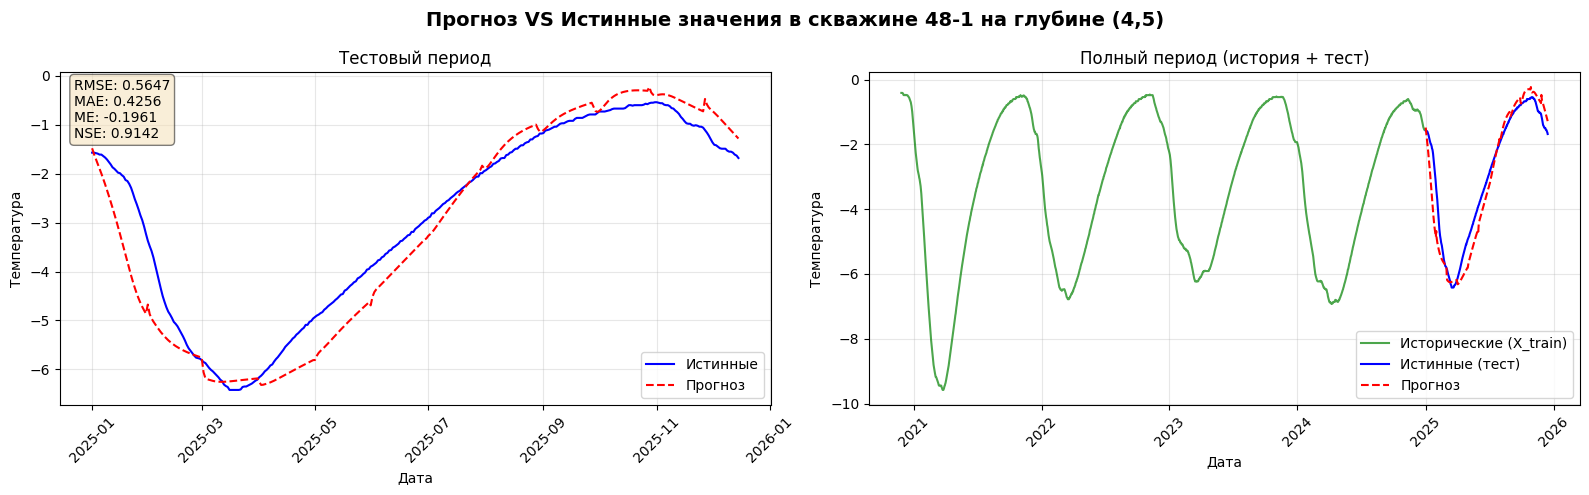

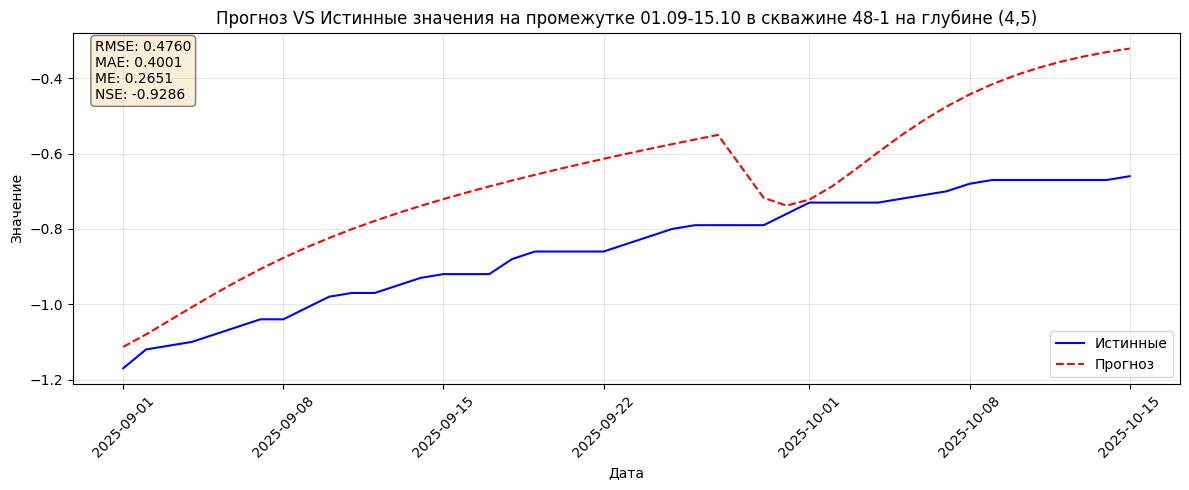

      48-1 (5)
RMSE  0.536322
MAE   0.391543
ME   -0.189077
NSE   0.914483


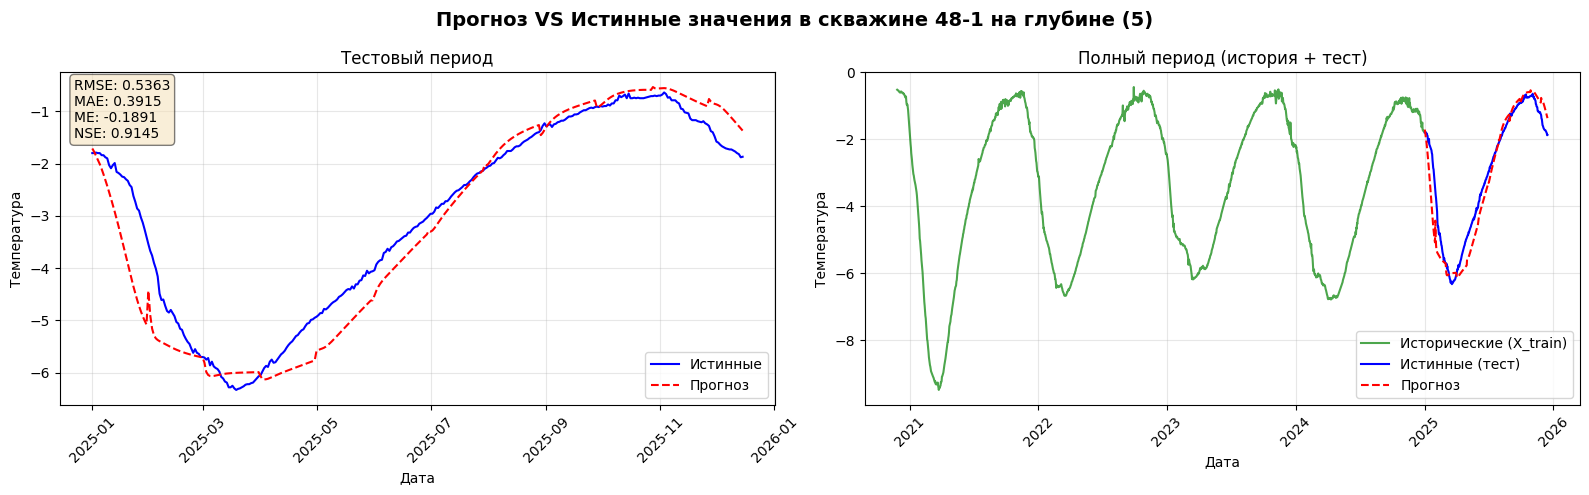

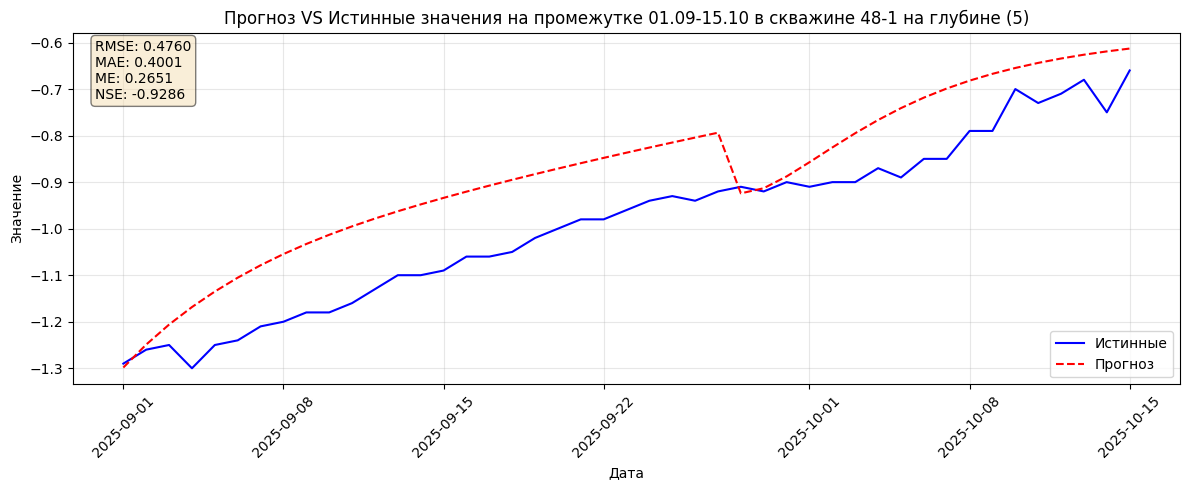

      48-1 (6)
RMSE  0.439981
MAE   0.325652
ME    -0.12978
NSE   0.931129


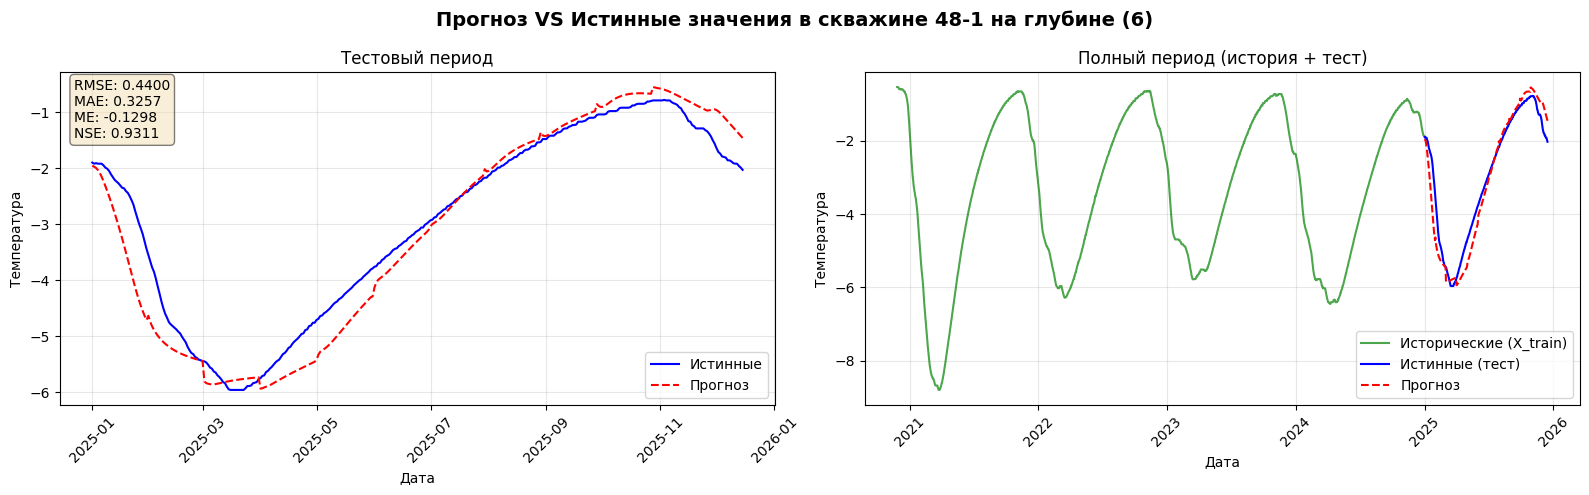

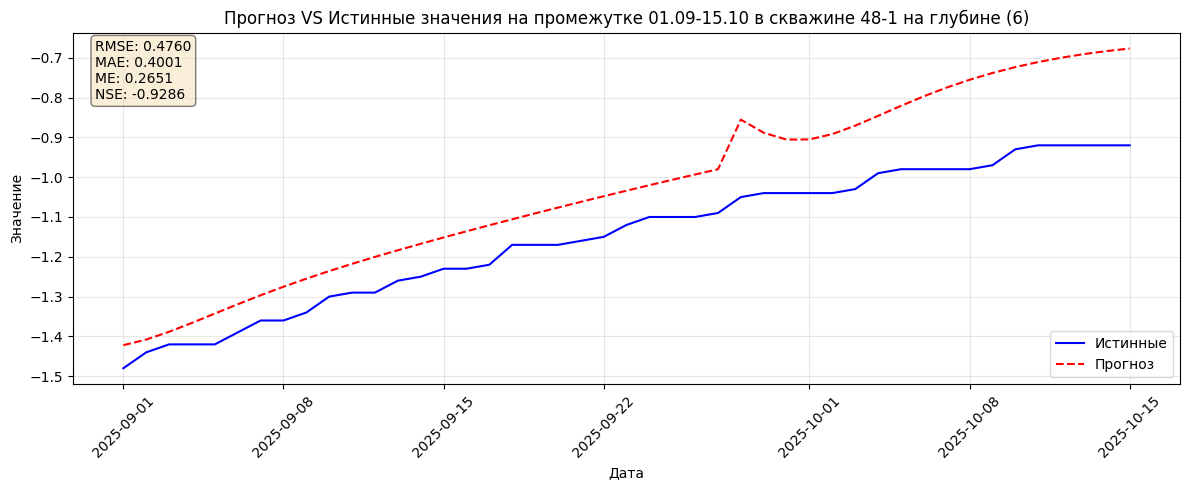

      48-1 (7)
RMSE  0.393332
MAE   0.302796
ME   -0.098937
NSE   0.932826


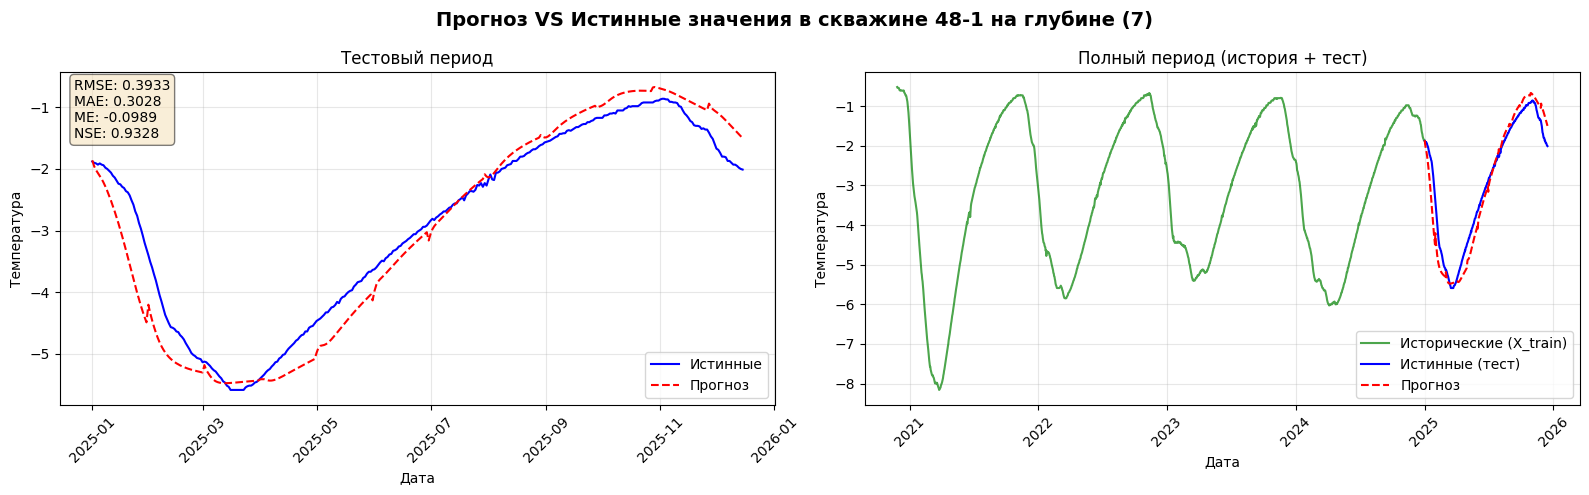

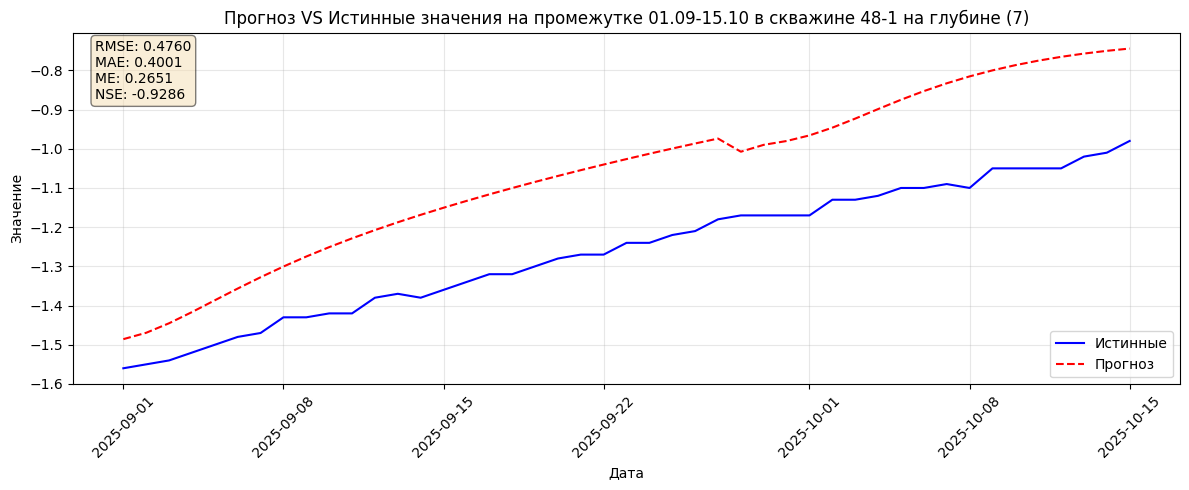

      48-1 (8)
RMSE  0.375897
MAE   0.299522
ME   -0.070195
NSE   0.919027


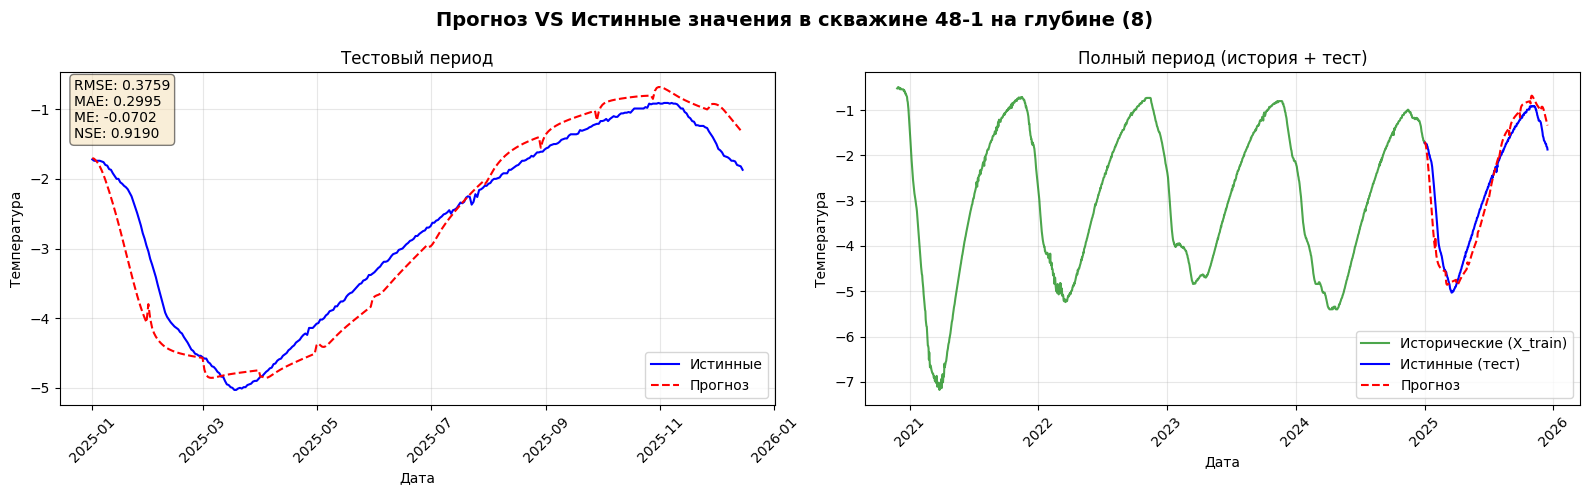

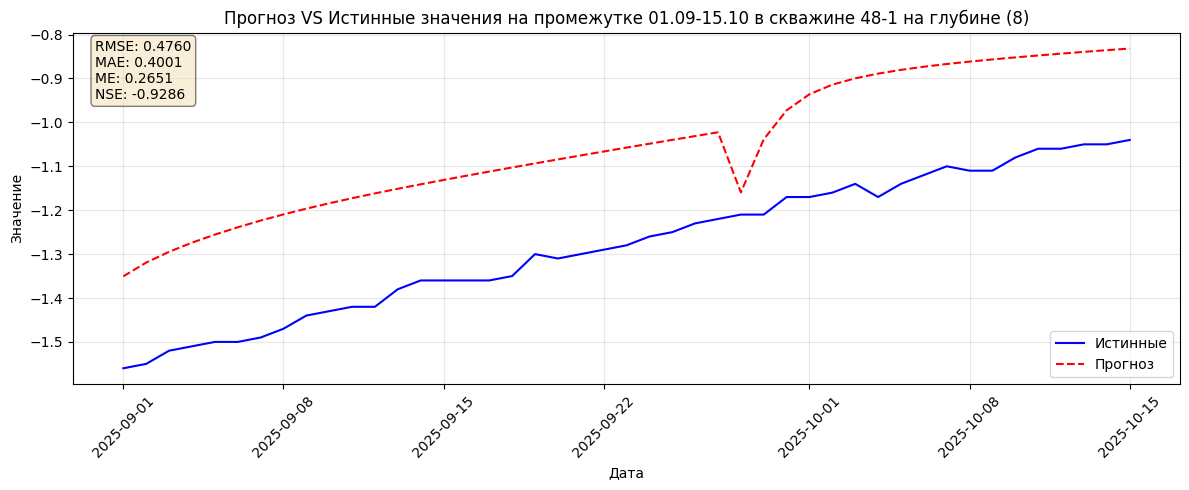

      48-1 (9)
RMSE  0.291268
MAE   0.241388
ME   -0.028837
NSE   0.926932


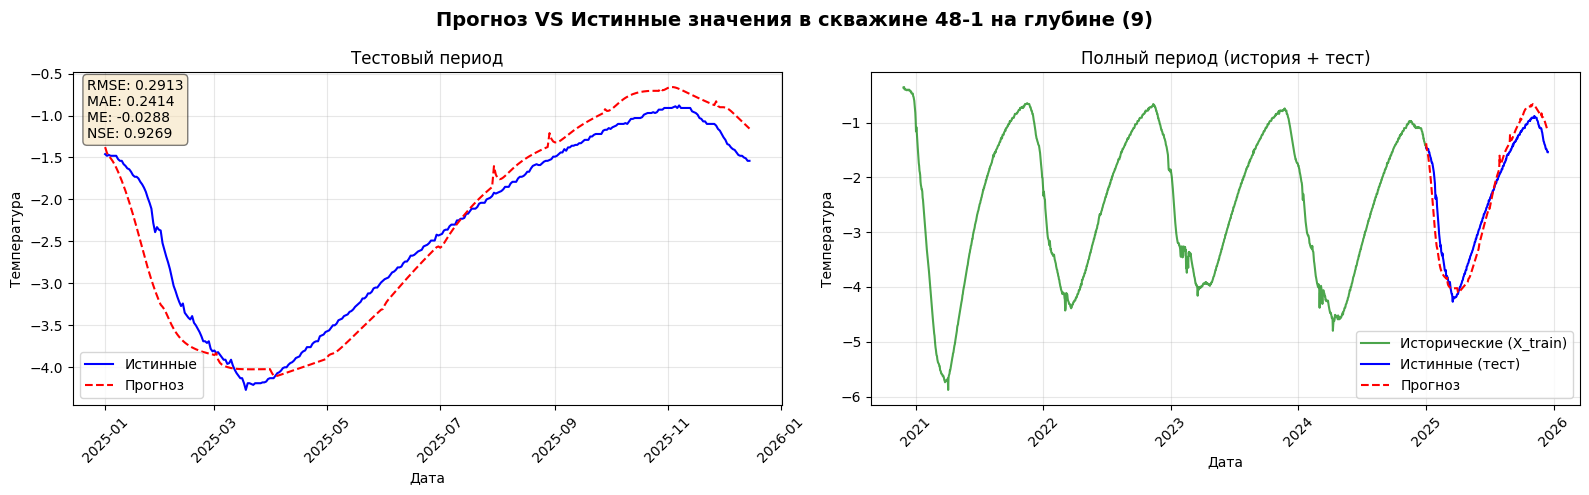

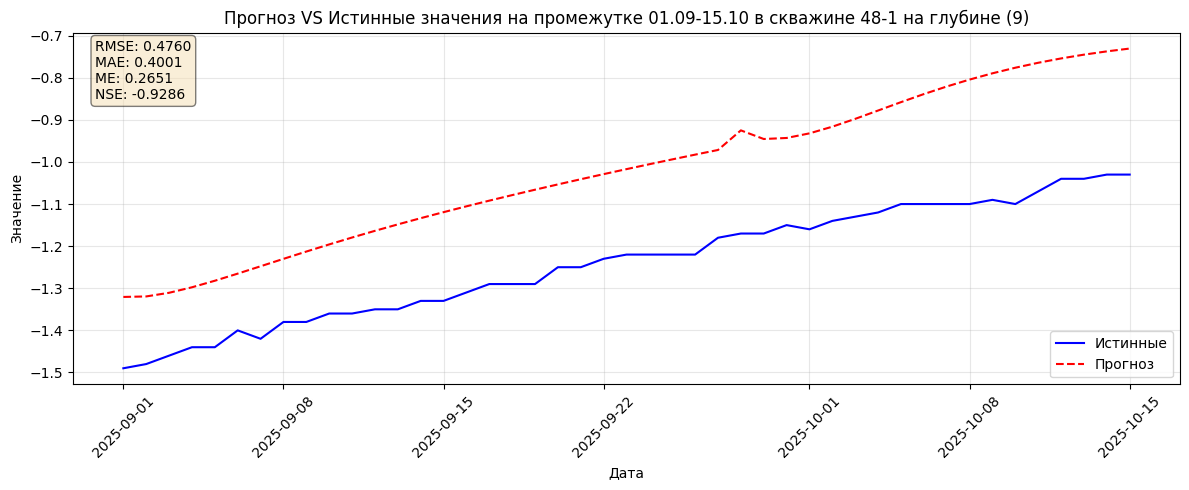

     48-1 (10)
RMSE  0.195752
MAE   0.159369
ME    0.027085
NSE   0.946189


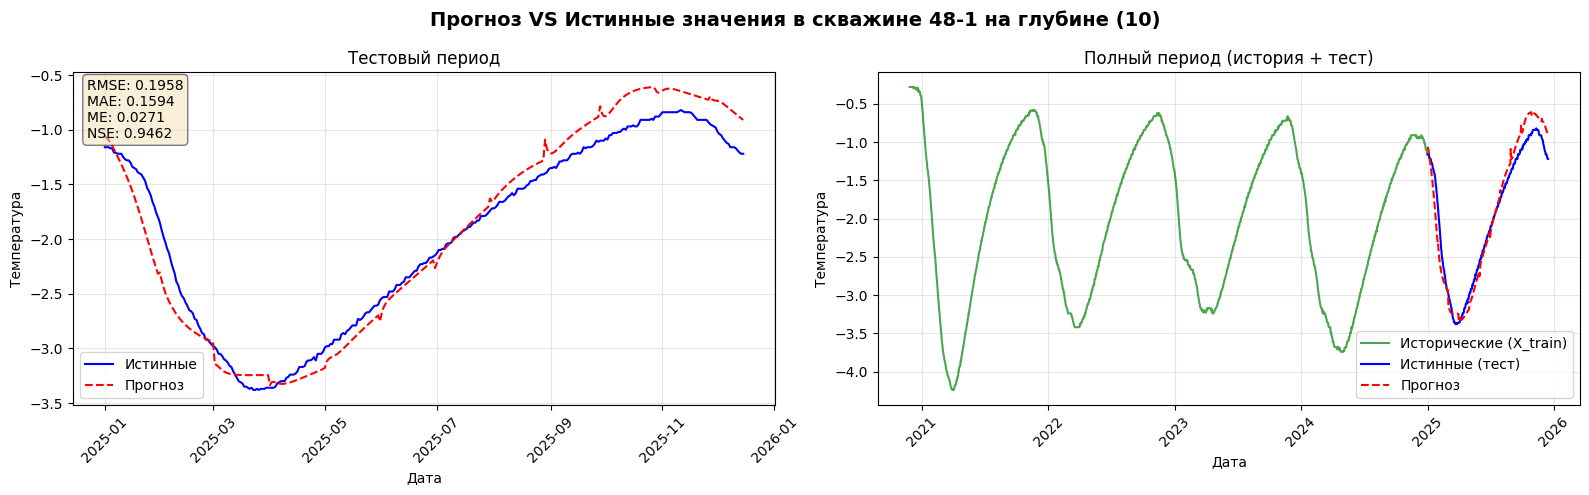

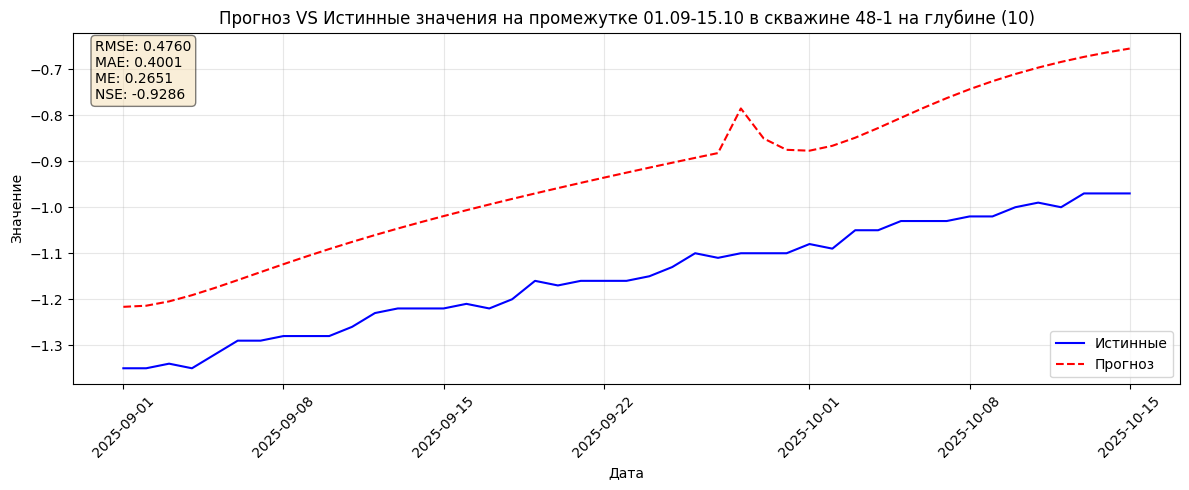

In [80]:
y_pred = predict_seq2seq(
    model=model,
    df_history=df_val,
    df_test=df_test,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    feature_cols=feature_cols,
    target_cols=target_cols,
    history_len=history_len,
    horizon=horizon,
    device=device,
)
y_true = df_test[target_cols]

eval_dict = evaluate(y_true, y_pred)
print(pd.DataFrame(eval_dict, index=['Значение для всех глубин']))

eval_by_depth_df = evaluate_by_depth(y_true.values, y_pred.values, target_cols)
y_true_autumn = y_true['2025-09-01':'2025-10-15']
y_pred_autumn = y_pred['2025-09-01':'2025-10-15']
metrics_autumn = evaluate(y_true_autumn.values, y_pred_autumn.values)
for i, col in enumerate(target_cols):
    metrics = eval_by_depth_df.loc[col]
    print(metrics.to_frame()[1:])
    
    plot_forecast_with_train(
        df_train_full[col],
        pd.DataFrame(y_true[col]),
        pd.DataFrame(y_pred[col]),
        metrics_dict=metrics[1:].to_dict(),
        title=f'Прогноз VS Истинные значения в скважине {col.split()[0]} на глубине {col.split()[1]}'
    )
    plot_forecast(
        pd.DataFrame(y_true_autumn[col]),
        pd.DataFrame(y_pred_autumn[col]),
        metrics_dict=metrics_autumn,
        title=f'Прогноз VS Истинные значения на промежутке 01.09-15.10 в скважине {col.split()[0]} на глубине {col.split()[1]}'
    )